# Краткий отчет

В ходе выполнения дз были выполнены следующие шаги:

1) обработаны данные (отсмотрены на корреляции, разобрались с типом данных object, который мешал обработке, а также выявлена несбалансированность данных);

2) опробованы несколько моделей (RandomForestClassifier и XGBClassifier - с каждым работали через RandomizedSearchCV для ускорения работы, были отсмотрены различные параметры моделей, а также произведен анализ и отбор фичей; с RandomForestClassifier было сильное переобучение и score был около 0.6 на тестовой, с XGBClassifier score получилось поднять до 0.75)

3) произведена дальнейшая обработка тестовых данных и их классификация на модели с лучшими показателями

# Начальные настройки

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

advanced_dls_spring_2021_path = kagglehub.competition_download('advanced-dls-spring-2021')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import seaborn as sns
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advanced-dls-spring-2021/submission.csv
/kaggle/input/advanced-dls-spring-2021/train.csv
/kaggle/input/advanced-dls-spring-2021/test.csv


In [ ]:
train_data = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv')
train_data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


#  Предобработка данных

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

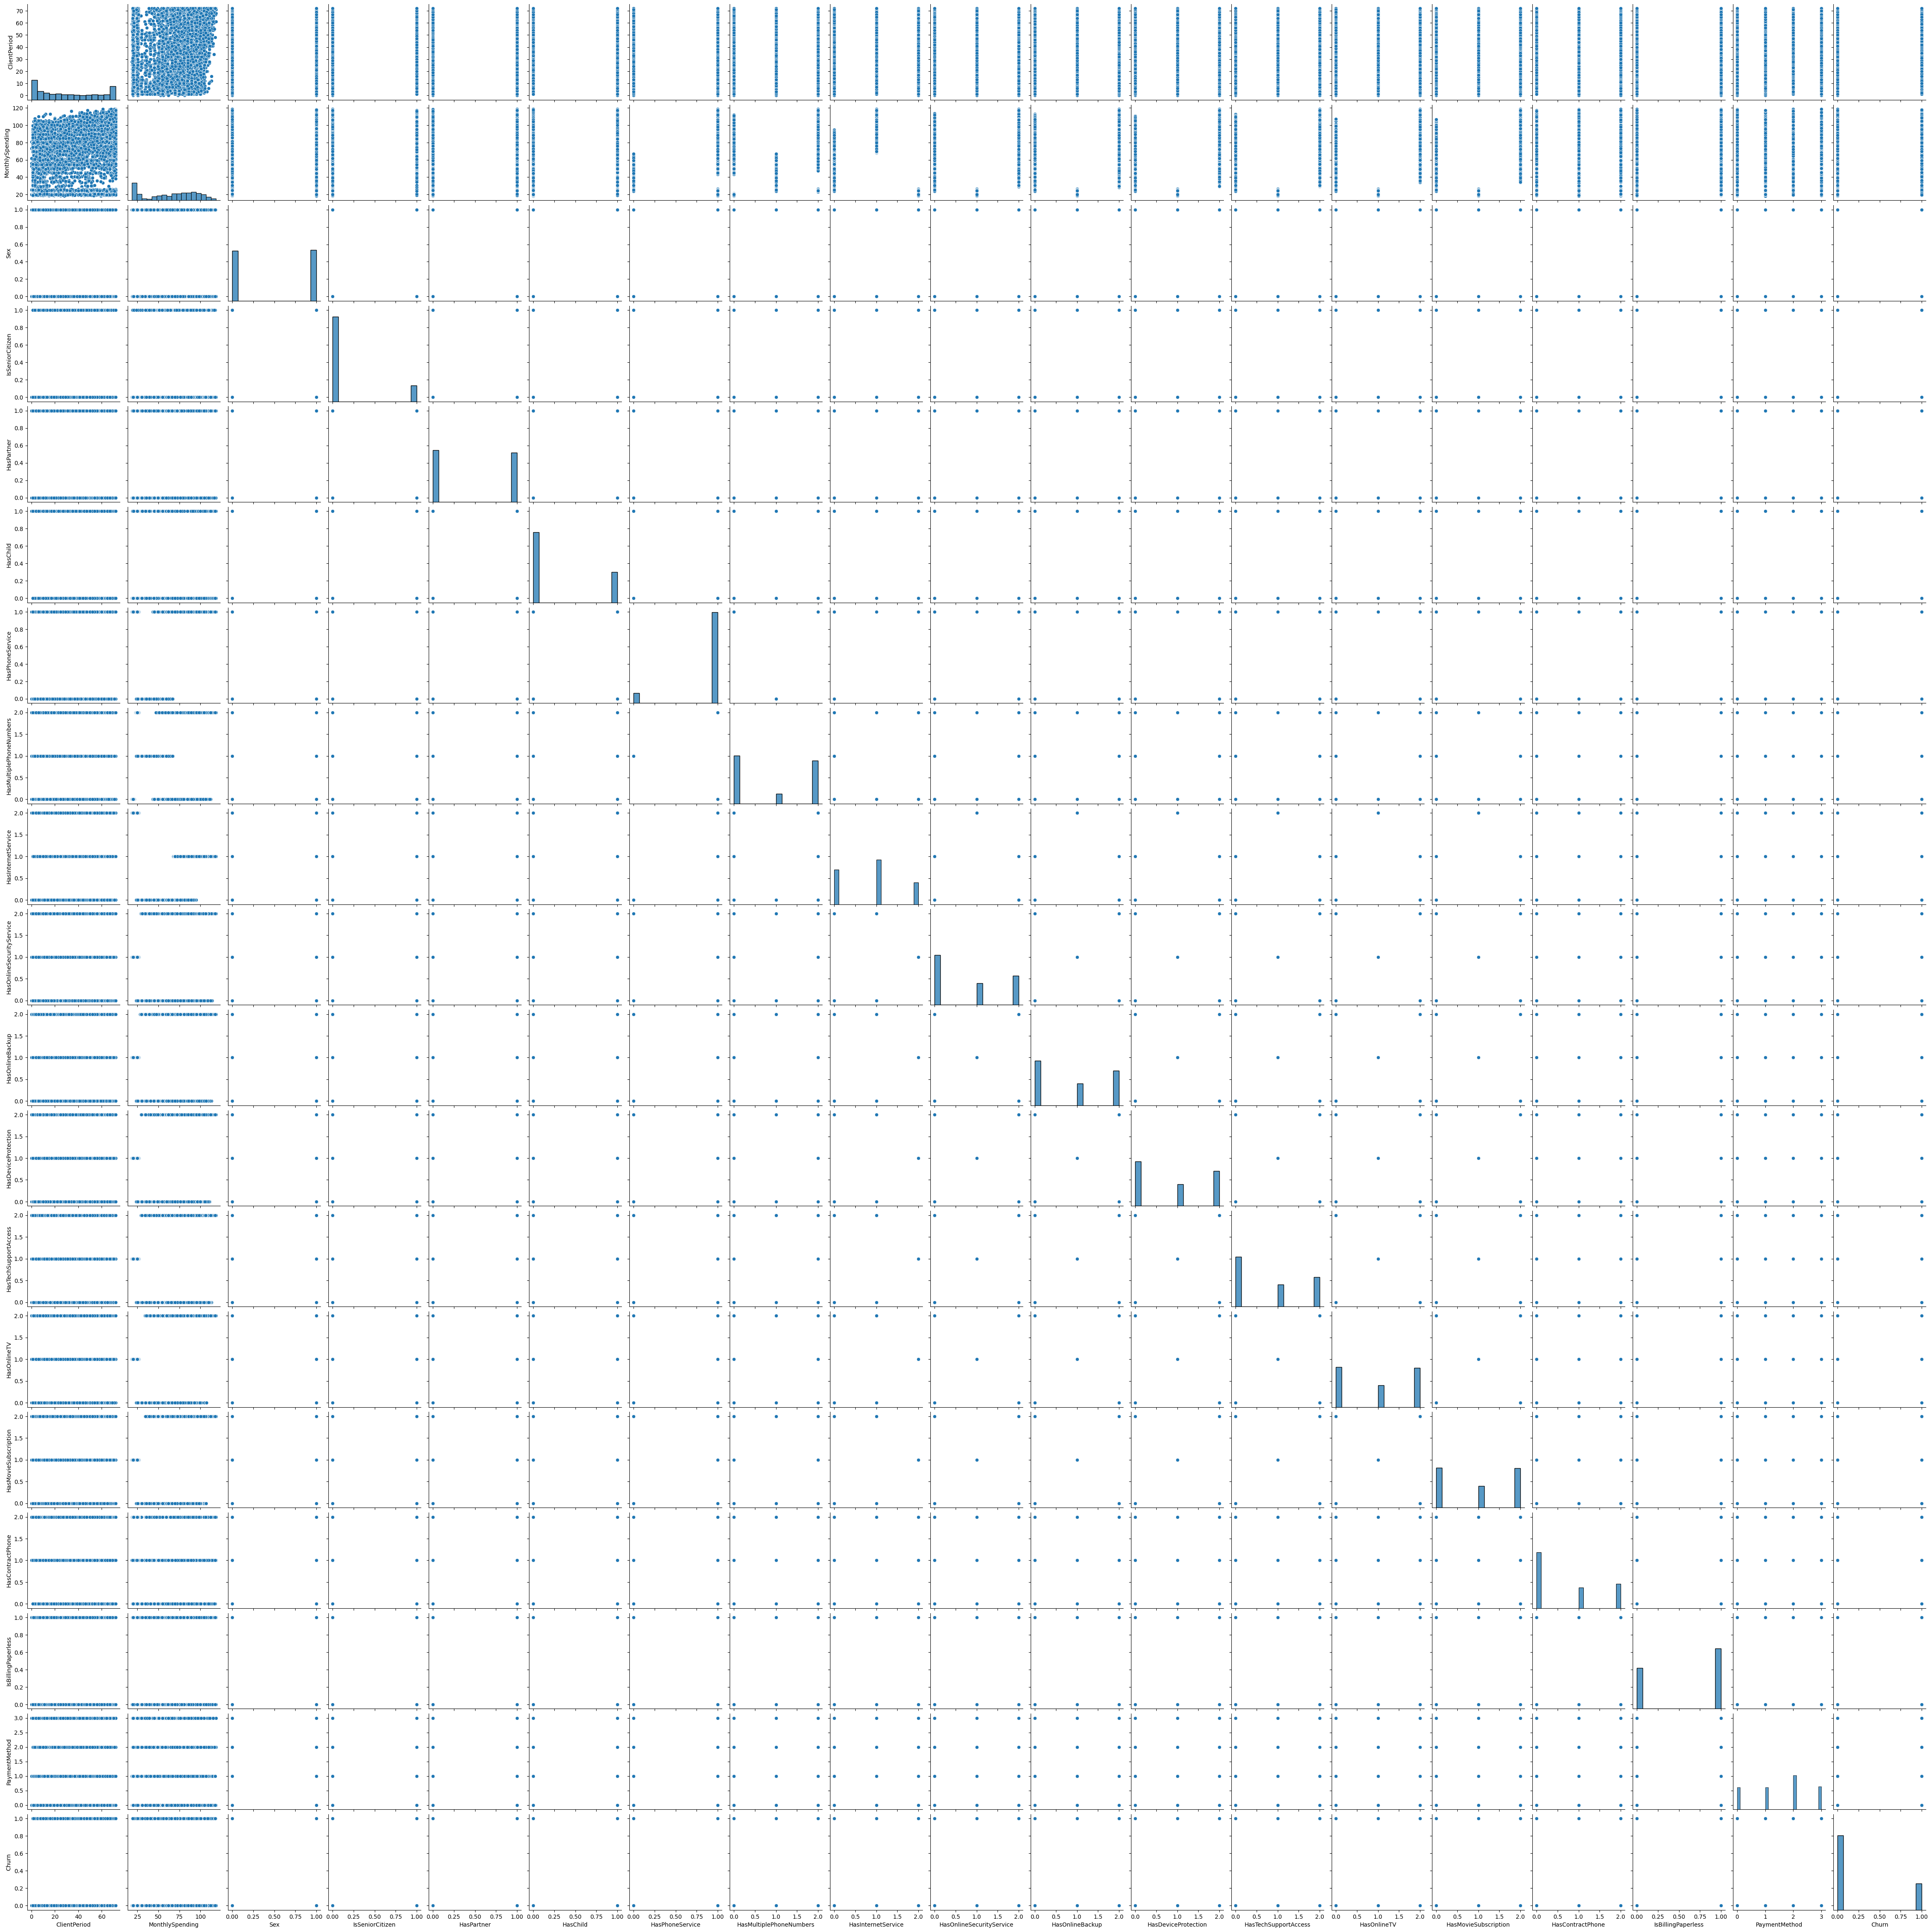

In [ ]:
#отсматриваем на корреляции
sns.pairplot(train_data)

In [ ]:
#используем LabelEncoder т.к.
#one_hot_encoder добавляет слишком много cтолбцов
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

cat = ['Sex', 'IsSeniorCitizen', 'HasPartner', 'HasChild', 'HasPhoneService', 'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'IsBillingPaperless', 'PaymentMethod']
for column in cat:
    train_data[column] = label_encoder.fit_transform( train_data[column])

In [ ]:
#разбираемся с типом данных object
train_data['TotalSpent'] = (
    train_data['TotalSpent']
    .str.replace(' ', '')  # Убираем пробелы
)

# Преобразование в float
train_data['TotalSpent'] = pd.to_numeric(train_data['TotalSpent'], errors='coerce')

In [ ]:
train_data = train_data.fillna({'TotalSpent': train_data['TotalSpent'].mean()})

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


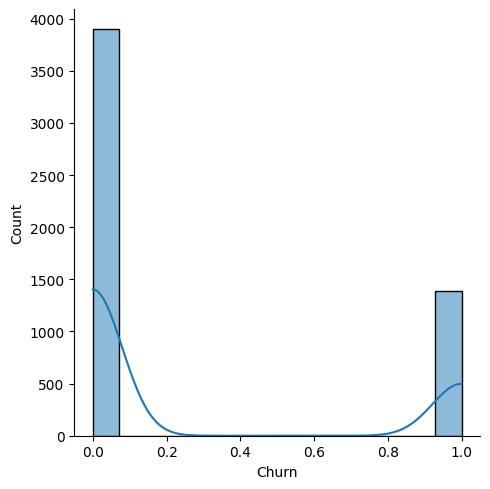

In [ ]:
# отсматриваем сбалансированность данных и выясняем,
# что они несбалансированы -
# будем работать над этим при построении модели
sns.displot(train_data, x=train_data.Churn.dropna(), kde=True)

In [ ]:
#отсматриваем на корреляции
# correlation matrix
#k = 10 # number of variables for heatmap
#cols = corrmat.nlargest(k, 'Churn')['Churn'].index
#cm = np.corrcoef(train_data[cols].values.T)
#sns.set(font_scale=1.25)
#hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
#plt.show()

# Работа с моделями

In [ ]:
drop_list = ['Churn',
             #'HasPhoneService',
             'HasDeviceProtection',
             'HasPartner',
             #'Sex',
             #'HasOnlineTV',
             #'TotalSpent',
             #'PaymentMethod',
             #'MonthlySpending',
             #'HasChild',
            ]
x_train_new = train_data.drop(drop_list, axis = 1)
y_train_new = train_data.Churn

Изначально выбор пал на RandomForestClassifier, однако не получалось подобрать параметры таким образом, чтобы получить score выше 0.6 - было принято решение использовать XGBClassifier (но и там score не особо выше получился :/ ).

In [ ]:
from xgboost import XGBClassifier

params = {
    'n_estimators': range(20, 80),
    'max_depth': range(1, 10),
    'learning_rate': [0.01, 0.1, 0.15, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1]
}

#scale_pos_weight - необходим, чтобы избавиться от несбалансированности
scale_pos_weight = len(y_train_new[y_train_new == 0]) / len(y_train_new[y_train_new == 1])

model = XGBClassifier(random_state=0,
                      n_jobs=-1,
                      early_stopping_rounds=10,
                      scale_pos_weight=scale_pos_weight,
                      )
search = RandomizedSearchCV(model, params, n_iter=50, cv=5, random_state=0, n_jobs=-1)
search.fit(x_train_new, y_train_new,
           eval_set=[(x_train_new, y_train_new)],
           verbose=True)
best_model_new = search.best_estimator_
best_model_new.score(x_train_new, y_train_new)

[0]	validation_0-logloss:0.59895
[1]	validation_0-logloss:0.53209
[2]	validation_0-logloss:0.48306
[3]	validation_0-logloss:0.44416
[4]	validation_0-logloss:0.41426
[5]	validation_0-logloss:0.38727
[6]	validation_0-logloss:0.36428
[7]	validation_0-logloss:0.34547
[8]	validation_0-logloss:0.33219
[9]	validation_0-logloss:0.31852
[10]	validation_0-logloss:0.30710
[11]	validation_0-logloss:0.29690
[12]	validation_0-logloss:0.28857
[13]	validation_0-logloss:0.28202
[14]	validation_0-logloss:0.27496
[15]	validation_0-logloss:0.26600
[16]	validation_0-logloss:0.25959
[17]	validation_0-logloss:0.25045
[18]	validation_0-logloss:0.24758
[19]	validation_0-logloss:0.24424
[20]	validation_0-logloss:0.23937
[21]	validation_0-logloss:0.23723
[22]	validation_0-logloss:0.23453
[23]	validation_0-logloss:0.23092
[24]	validation_0-logloss:0.22611
[25]	validation_0-logloss:0.22301
[26]	validation_0-logloss:0.22175
[27]	validation_0-logloss:0.21821
[28]	validation_0-logloss:0.21693
[29]	validation_0-loglos

0.9727375993941689

In [ ]:
#отсматривает признаки на важность и выбвигаем гипотезу, что они не все нужны;
#играемся с фичами в drop_list и смотрим на score
#выбираем вариант с лучшим показателем
importances = best_model_new.feature_importances_
feature_importance_df = pd.DataFrame({'feature': x_train_new.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
16          HasContractPhone    0.390177
10  HasOnlineSecurityService    0.162228
9         HasInternetService    0.075385
15      HasMovieSubscription    0.044289
13      HasTechSupportAccess    0.035668
0               ClientPeriod    0.030128
11           HasOnlineBackup    0.028858
8    HasMultiplePhoneNumbers    0.023530
17        IsBillingPaperless    0.022630
2                 TotalSpent    0.020997
14               HasOnlineTV    0.020882
4            IsSeniorCitizen    0.020319
1            MonthlySpending    0.019446
3                        Sex    0.018982
18             PaymentMethod    0.018916
7            HasPhoneService    0.018067
6                   HasChild    0.017783
12       HasDeviceProtection    0.017580
5                 HasPartner    0.014135


# Работа с тестовыми данными

In [ ]:
test_data = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv')
test_data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
0,42,56.10,2386.85,Male,0,Yes,No,Yes,Yes,DSL,Yes,No,No,No,No,No,One year,No,Credit card (automatic)
1,29,98.50,3004.15,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
2,9,76.25,684.85,Male,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3,67,74.00,4868.4,Female,0,Yes,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic)
4,71,20.10,1389.6,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic)


In [ ]:

label_encoder = LabelEncoder()

cat = ['Sex', 'IsSeniorCitizen', 'HasPartner', 'HasChild', 'HasPhoneService', 'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'IsBillingPaperless', 'PaymentMethod']
for column in cat:
    test_data[column] = label_encoder.fit_transform( test_data[column])

In [ ]:
#разбираемся с типом данных object
test_data['TotalSpent'] = (
    test_data['TotalSpent']
    .str.replace(' ', '')  # Убираем пробелы
)

# Преобразование в float
test_data['TotalSpent'] = pd.to_numeric(test_data['TotalSpent'], errors='coerce')
test_data = test_data.fillna({'TotalSpent': test_data['TotalSpent'].mean()})

In [ ]:
test_data_new = test_data.drop(drop_list[1:], axis = 1)

In [ ]:
test_predictions = best_model_new.predict(test_data_new)

submission = pd.DataFrame({
    'Id': range(0, len(test_predictions)),
    'Churn': test_predictions
})

submission.to_csv('submission.csv', index=False)

In [ ]:
submission.head()

In [ ]:
sub_data = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/submission.csv')
sub_data.head()

,Id,Churn
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5
